# 🎬 Chương 3 - Dataset 2: IMDB Reviews - Bidirectional GRU
## Kỹ thuật: GloVe Embeddings + Bidirectional GRU

**Pipeline:** EDA → WordCloud → GloVe Embedding Matrix → BiGRU → Train → Evaluate

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import re, os, glob, warnings

import nltk
from nltk.corpus import stopwords


import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

DATA_DIR = '../data/imdb_reviews'
SAVE_DIR = '../results/imdb_bigru'
os.makedirs(SAVE_DIR, exist_ok=True)

VOCAB_SIZE = 20000
MAX_LEN    = 500
EMBED_DIM  = 100   # GloVe 100d
EPOCHS     = 15
BATCH_SIZE = 128

print(f"TF: {tf.__version__} | Seed = {SEED}")

I0000 00:00:1780136583.951298 2779242 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780136583.987865 2779242 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780136584.791989 2779242 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF: 2.21.0 | Seed = 42


## 📂 1. Load IMDB Data

In [2]:
csv_files = glob.glob(f'{DATA_DIR}/**/*.csv', recursive=True) + glob.glob(f'{DATA_DIR}/*.csv')
print('Found:', csv_files)
df = pd.read_csv(csv_files[0])
print(f'Shape: {df.shape}')

pd.set_option('display.max_colwidth', None)
df.head(10)

Found: ['../data/imdb_reviews/IMDB Dataset.csv', '../data/imdb_reviews/IMDB Dataset.csv']
Shape: (50000, 2)


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her ""sexy"" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than ""Devil Wears Prada"" and more interesting than ""Superman"" a great comedy to go see with friends.",positive
3,"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zom

In [3]:
# Identify columns
text_col  = [c for c in df.columns if any(k in c.lower() for k in ['review','text','comment'])][0]
label_col = [c for c in df.columns if any(k in c.lower() for k in ['sentiment','label','rating'])][0]
print(f'Text: {text_col}, Label: {label_col}')
print(df[label_col].value_counts())

df = df[[text_col, label_col]].dropna()
df.columns = ['text', 'label']

# Binary encode
if df['label'].dtype == object:
    positive_keys = ['positive', 'pos', '1', 'good']
    df['label'] = df['label'].str.lower().apply(
        lambda x: 1 if any(k in x for k in positive_keys) else 0)

print(f'Label distribution:\n{df["label"].value_counts()}')

Text: review, Label: sentiment
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Label distribution:
label
1    25000
0    25000
Name: count, dtype: int64


## 📊 2. EDA

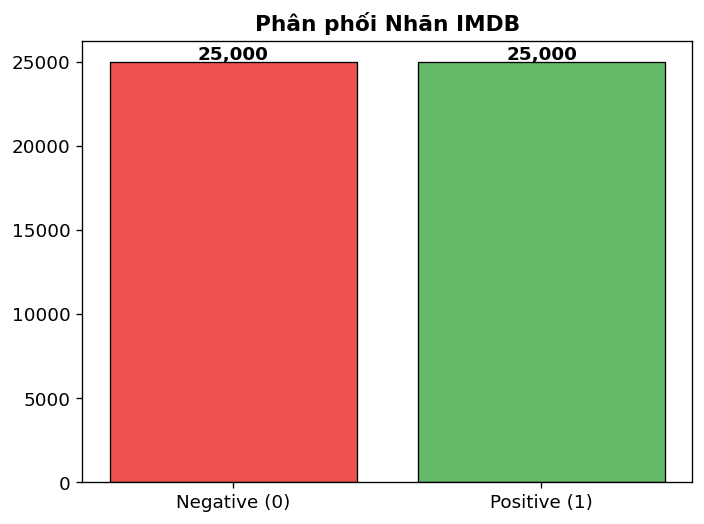

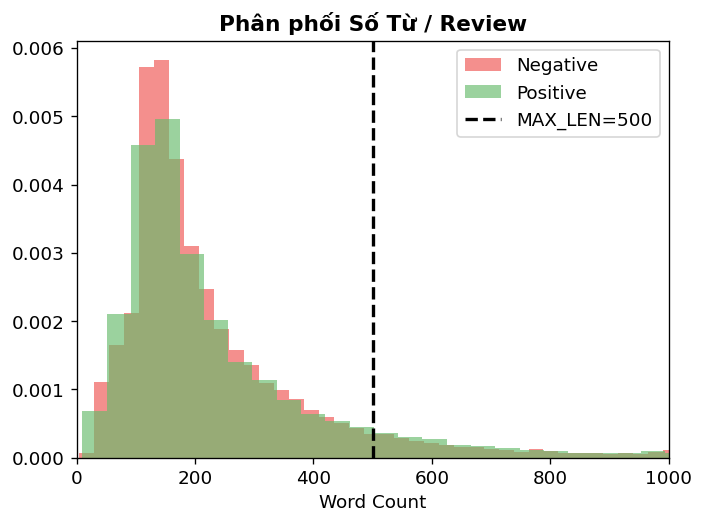

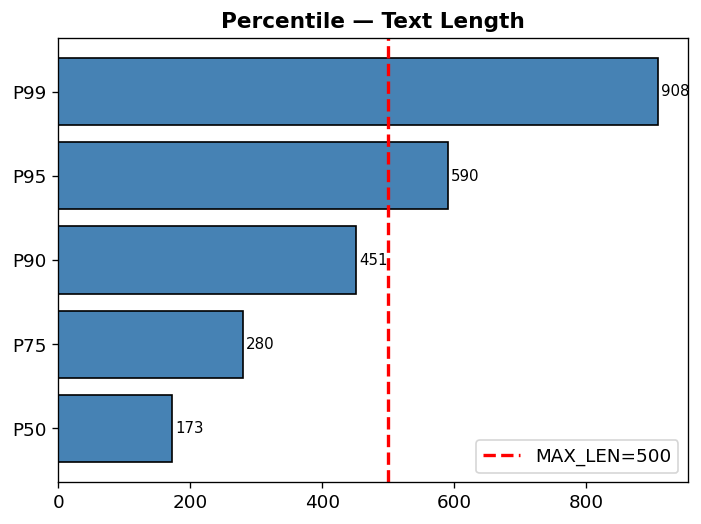

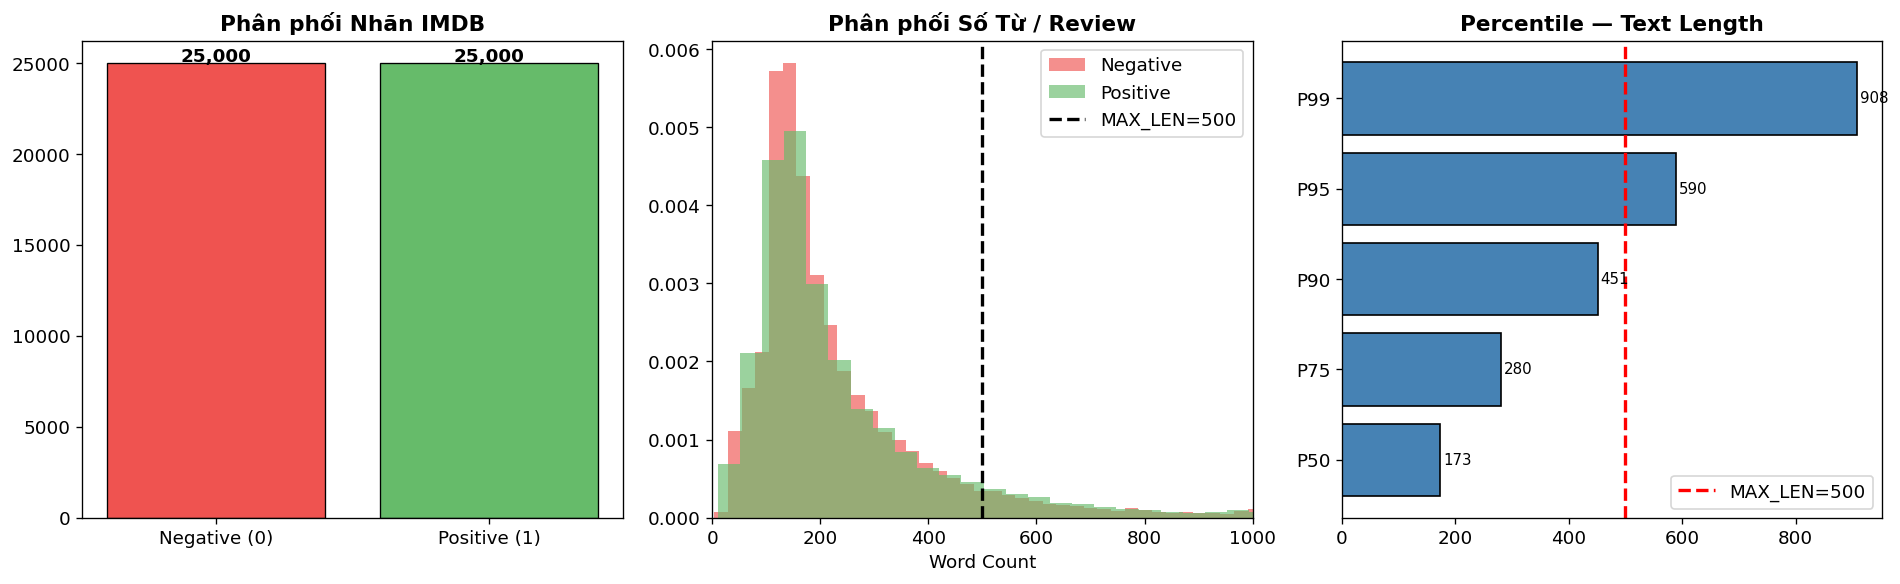

In [ ]:
df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))
df['char_len'] = df['text'].apply(lambda x: len(str(x)))

# 1. Phân phối Nhãn IMDB
plt.figure(figsize=(6, 4.5))
counts = df['label'].value_counts().sort_index()
plt.bar(['Negative (0)', 'Positive (1)'], counts.values,
        color=['#EF5350', '#66BB6A'], edgecolor='black', linewidth=0.8)
for i, val in enumerate(counts.values):
    plt.text(i, val+100, f'{val:,}', ha='center', fontweight='bold')
plt.title('Phân phối Nhãn IMDB')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_eda_label_dist.png', bbox_inches='tight')
plt.show()

# 2. Phân phối Số Từ / Review
plt.figure(figsize=(6, 4.5))
for lbl, color, name in [(0,'#EF5350','Negative'), (1,'#66BB6A','Positive')]:
    plt.hist(df[df['label']==lbl]['text_len'],
             bins=60, alpha=0.65, color=color, label=name, density=True)
plt.axvline(MAX_LEN, color='black', linestyle='--', lw=2, label=f'MAX_LEN={MAX_LEN}')
plt.title('Phân phối Số Từ / Review')
plt.xlabel('Word Count')
plt.legend()
plt.xlim(0, 1000)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_eda_word_len_dist.png', bbox_inches='tight')
plt.show()

# 3. Percentile - Text Length
plt.figure(figsize=(6, 4.5))
percentiles = [50, 75, 90, 95, 99]
pct_values  = np.percentile(df['text_len'], percentiles)
plt.barh([f'P{p}' for p in percentiles], pct_values,
         color='steelblue', edgecolor='black')
plt.axvline(MAX_LEN, color='red', linestyle='--', lw=2, label=f'MAX_LEN={MAX_LEN}')
plt.title('Percentile - Text Length')
plt.legend()
for i, v in enumerate(pct_values):
    plt.text(v+5, i, f'{v:.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_eda_percentile_len.png', bbox_inches='tight')
plt.show()

# Save overview plot for backward compatibility with LaTeX reports
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].bar(['Negative (0)', 'Positive (1)'], counts.values,
            color=['#EF5350', '#66BB6A'], edgecolor='black', linewidth=0.8)
for i, val in enumerate(counts.values):
    axes[0].text(i, val+100, f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('Phân phối Nhãn IMDB')

for lbl, color, name in [(0,'#EF5350','Negative'), (1,'#66BB6A','Positive')]:
    axes[1].hist(df[df['label']==lbl]['text_len'],
                 bins=60, alpha=0.65, color=color, label=name, density=True)
axes[1].axvline(MAX_LEN, color='black', linestyle='--', lw=2, label=f'MAX_LEN={MAX_LEN}')
axes[1].set_title('Phân phối Số Từ / Review')
axes[1].set_xlabel('Word Count')
axes[1].legend()
axes[1].set_xlim(0, 1000)

axes[2].barh([f'P{p}' for p in percentiles], pct_values,
              color='steelblue', edgecolor='black')
axes[2].axvline(MAX_LEN, color='red', linestyle='--', lw=2, label=f'MAX_LEN={MAX_LEN}')
axes[2].set_title('Percentile - Text Length')
axes[2].legend()
for i, v in enumerate(pct_values):
    axes[2].text(v+5, i, f'{v:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_eda_overview.png', bbox_inches='tight')
plt.show()
plt.close(fig)

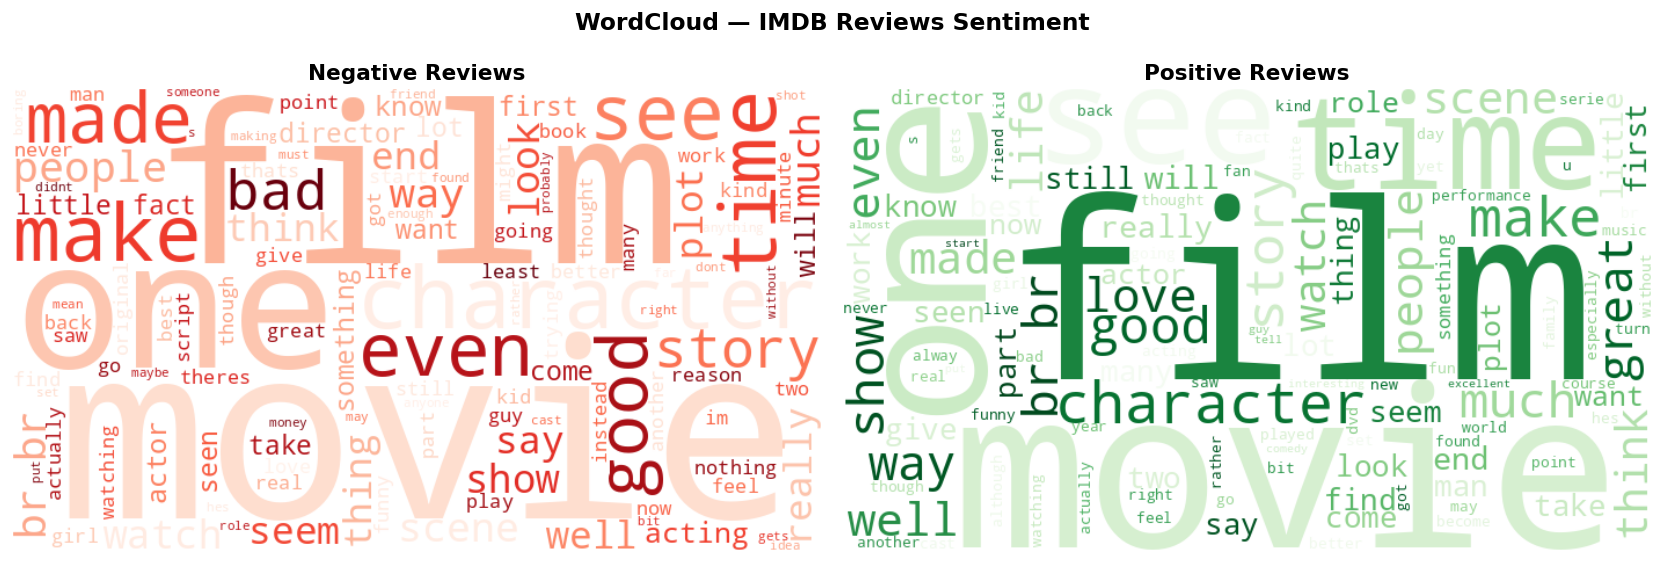

In [ ]:
# WordClouds before
def clean_text(text):
    return re.sub(r'[^a-z\s]', '', str(text).lower())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (lbl, title, cmap) in zip(axes, [
    (0, 'Negative Reviews', 'Reds'),
    (1, 'Positive Reviews', 'Greens')
]):
    corpus = ' '.join(df[df['label']==lbl]['text'].apply(clean_text).tolist())
    wc = WordCloud(width=700, height=400, max_words=120,
                   colormap=cmap, background_color='white').generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13)

plt.suptitle('WordCloud - IMDB Reviews Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_wordclouds_before_clean_text.png', bbox_inches='tight')
plt.show()

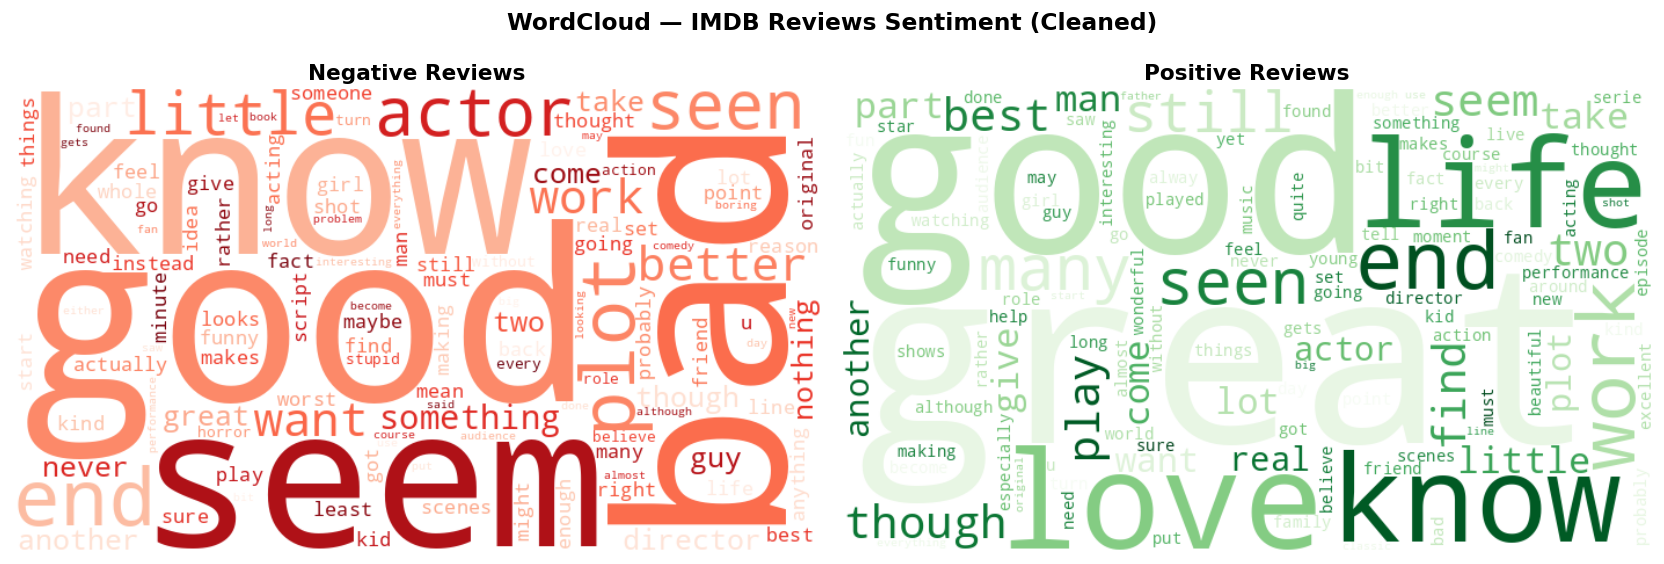

In [ ]:
# WordClouds after
stop_words = set(stopwords.words('english'))

# domain_stops = {'movie', 'film', 'one', 'character', 'make', 'even', 'time', 'watch', 'see', 'story', 'br', 'really', 'much', 'well'}
domain_stops = {
    'movie', 'film', 'one', 'character', 'make', 'even', 'time', 'watch', 
    'see', 'story', 'br', 'really', 'much', 'well', 
    'movies', 'films', 'characters', 'show', 'scene', 'people', 'think', 
    'way', 'made', 'look', 'say', 'first', 'thing'
}
stop_words = stop_words.union(domain_stops)

def clean_text2(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (lbl, title, cmap) in zip(axes, [
    (0, 'Negative Reviews', 'Reds'),
    (1, 'Positive Reviews', 'Greens')
]):
    corpus = ' '.join(df[df['label']==lbl]['text'].apply(clean_text2).tolist())
    wc = WordCloud(width=700, height=400, max_words=120,
                   colormap=cmap, background_color='white').generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13)

plt.suptitle('WordCloud - IMDB Reviews Sentiment (Cleaned)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_wordclouds_cleaned.png', bbox_inches='tight')
plt.show()

## ⚙️ 3. Preprocessing & GloVe Embedding

In [7]:
df['clean'] = df['text'].apply(clean_text)

X = df['clean'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train),
                             maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test),
                             maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Vocab size: {len(tokenizer.word_index):,}')
print(f'Train: {X_train_pad.shape}, Test: {X_test_pad.shape}')


Vocab size: 155,856
Train: (40000, 500), Test: (10000, 500)


In [ ]:
# GloVe
GLOVE_PATH = 'glove.6B.100d.txt'
embedding_matrix = None

if os.path.exists(GLOVE_PATH):
    print('Loading GloVe embeddings...')
    glove_dict = {}
    with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.split()
            glove_dict[parts[0]] = np.array(parts[1:], dtype='float32')

    embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
    hits = 0
    for word, idx in tokenizer.word_index.items():
        if idx < VOCAB_SIZE and word in glove_dict:
            embedding_matrix[idx] = glove_dict[word]
            hits += 1
    print(f'GloVe hit rate: {hits}/{min(VOCAB_SIZE, len(tokenizer.word_index)):,} words ({hits/min(VOCAB_SIZE, len(tokenizer.word_index))*100:.1f}%)')
    USE_GLOVE = True
else:
    print('⚠️  GloVe not found - using trainable embedding instead.')
    print('   (Download: https://nlp.stanford.edu/data/glove.6B.zip)')
    USE_GLOVE = False

Loading GloVe embeddings...
GloVe hit rate: 18778/20,000 words (93.9%)


## 🏗️ 4. Bidirectional GRU Model

In [9]:
# Build embedding layer
if USE_GLOVE and embedding_matrix is not None:
    embed_layer = layers.Embedding(
        VOCAB_SIZE, EMBED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False,   # Frozen GloVe
        name='glove_embedding'
    )
else:
    embed_layer = layers.Embedding(
        VOCAB_SIZE, EMBED_DIM,
        input_length=MAX_LEN,
        trainable=True,
        name='trainable_embedding'
    )

model = models.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    embed_layer,
    layers.SpatialDropout1D(0.2),
    layers.Bidirectional(layers.GRU(64, return_sequences=True), name='bigru_1'),
    layers.Dropout(0.3),
    layers.Bidirectional(layers.GRU(32), name='bigru_2'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid', name='output')
], name='BiGRU_IMDB')

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

I0000 00:00:1780136635.286633 2779242 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 999 MB memory:  -> device: 0, name: NVIDIA RTX 5880 Ada Generation, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1780136635.288236 2779242 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 46288 MB memory:  -> device: 1, name: NVIDIA RTX 5880 Ada Generation, pci bus id: 0000:41:00.0, compute capability: 8.9
I0000 00:00:1780136635.291257 2779242 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 698 MB memory:  -> device: 2, name: NVIDIA RTX 5880 Ada Generation, pci bus id: 0000:83:00.0, compute capability: 8.9


Model: "BiGRU_IMDB"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ (None, 500, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 500, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru_1 (Bidirectional)         │ (None, 500, 128)       │        63,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru_2 (Bidirectional)         │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,099,073 (8.01 MB)

 Trainable params: 99,073 (387.00 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

## 🚀 5. Training

In [10]:
history = model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
    ],
    verbose=1
)

Epoch 1/15


I0000 00:00:1780136640.119581 2824783 cuda_dnn.cc:461] Loaded cuDNN version 92101


250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.6436 - loss: 0.6201 - val_accuracy: 0.7869 - val_loss: 0.4719 - learning_rate: 0.0010
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.8026 - loss: 0.4386 - val_accuracy: 0.8321 - val_loss: 0.3778 - learning_rate: 0.0010
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.8323 - loss: 0.3820 - val_accuracy: 0.8330 - val_loss: 0.3561 - learning_rate: 0.0010
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.8440 - loss: 0.3583 - val_accuracy: 0.8351 - val_loss: 0.3536 - learning_rate: 0.0010
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.8546 - loss: 0.3393 - val_accuracy: 0.8566 - val_loss: 0.3182 - learning_rate: 0.0010
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.8649 - loss: 0.3190 - val_accuracy: 0.8569 - val_loss: 0.3094 - learning_rate: 0.0010
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.8719 - loss: 0.3059

## 📈 6. Evaluation

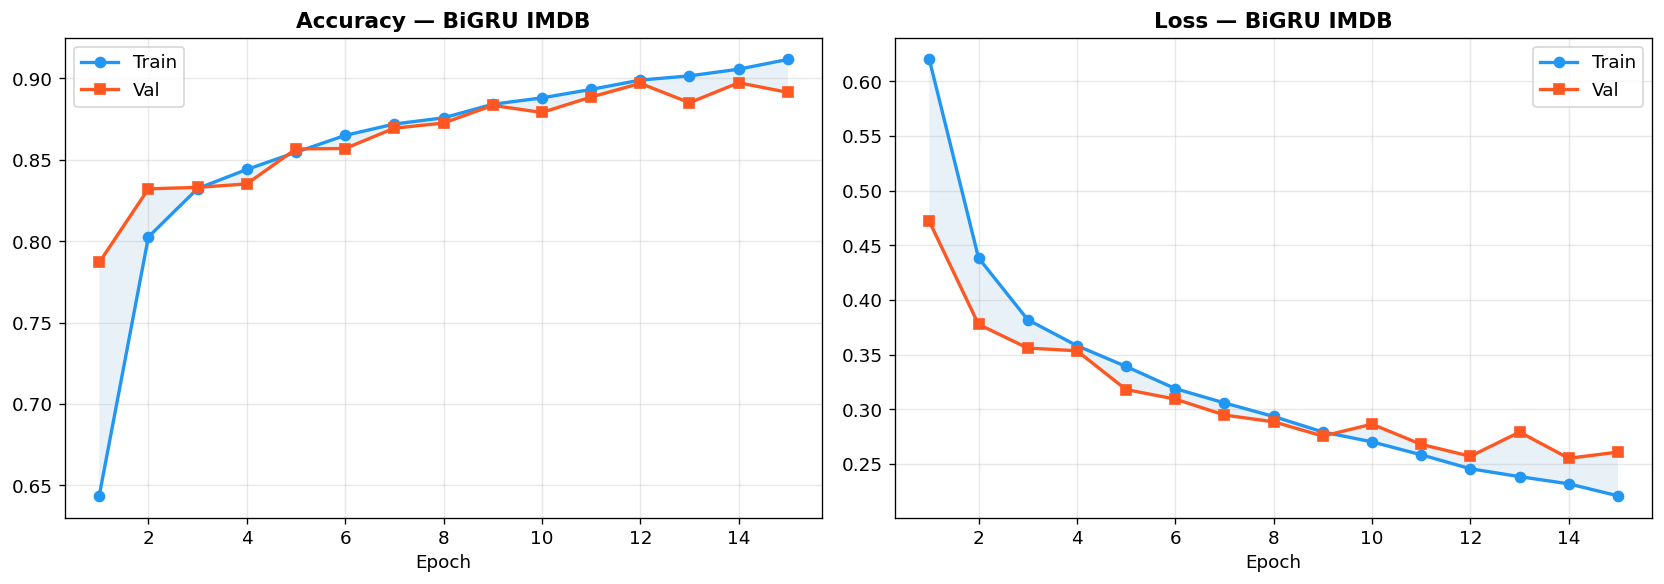

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eps = range(1, len(history.history['accuracy'])+1)
for ax, (tr, vl, metric) in zip(axes, [
    ('accuracy','val_accuracy','Accuracy'),
    ('loss','val_loss','Loss')
]):
    ax.plot(eps, history.history[tr], 'o-', color='#2196F3', lw=2, label='Train')
    ax.plot(eps, history.history[vl], 's-', color='#FF5722', lw=2, label='Val')
    ax.fill_between(eps, history.history[tr], history.history[vl], alpha=0.1)
    ax.set_title(f'{metric} - BiGRU IMDB')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_training_history.png', bbox_inches='tight')
plt.show()

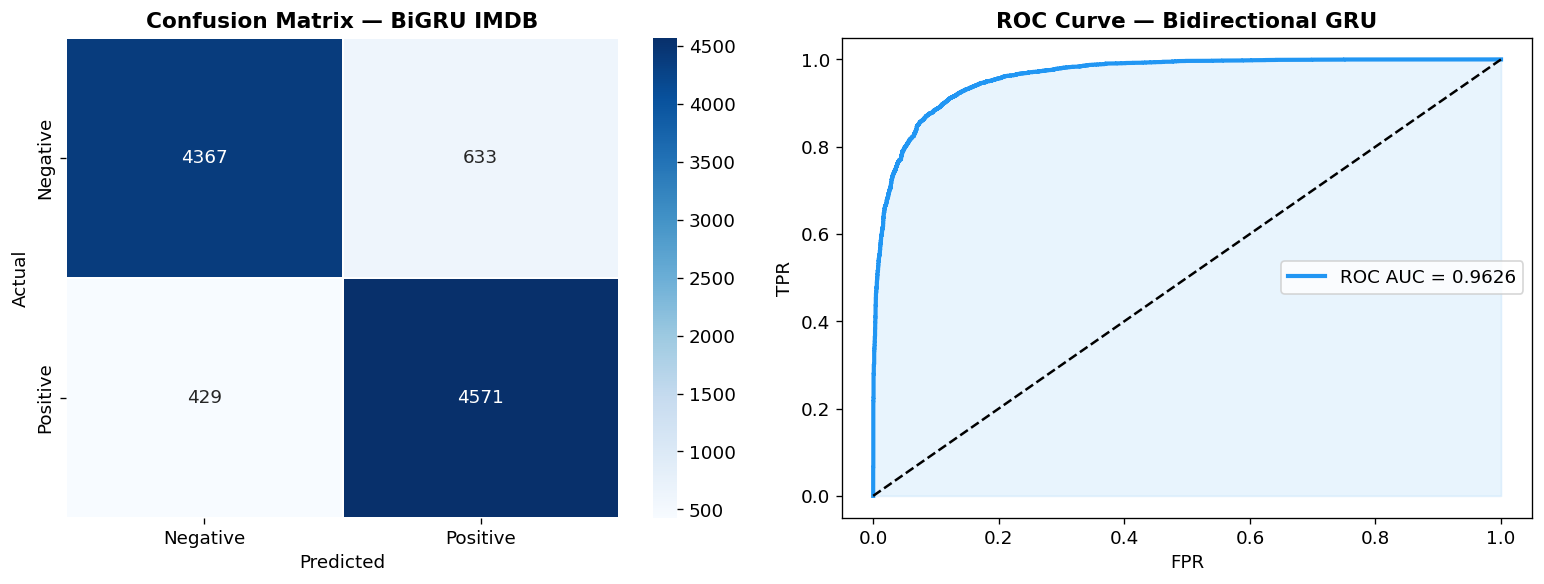

              precision    recall  f1-score   support

    Negative       0.91      0.87      0.89      5000
    Positive       0.88      0.91      0.90      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [ ]:
y_pred_prob = model.predict(X_test_pad, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc     = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'],
            linewidths=1, ax=axes[0])
axes[0].set_title('Confusion Matrix - BiGRU IMDB')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# ROC Curve
axes[1].plot(fpr, tpr, color='#2196F3', lw=2.5, label=f'ROC AUC = {roc_auc:.4f}')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
axes[1].plot([0,1],[0,1],'k--', lw=1.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve - Bidirectional GRU'); axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_confusion_roc.png', bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Negative','Positive']))

In [13]:
# Inference demo on new sentences
test_samples = [
    "This movie was absolutely fantastic! The acting was superb.",
    "Terrible film. Complete waste of time and money.",
    "It was okay, nothing special but not bad either."
]

cleaned  = [clean_text(s) for s in test_samples]
seqs     = pad_sequences(tokenizer.texts_to_sequences(cleaned),
                          maxlen=MAX_LEN, padding='post')
scores   = model.predict(seqs, verbose=0).flatten()

print('=== INFERENCE DEMO ===')
for s, score in zip(test_samples, scores):
    label = 'POSITIVE' if score >= 0.5 else 'NEGATIVE'
    print(f'Text  : {s[:60]}...')
    print(f'Score : {score:.4f} → {label}\n')

=== INFERENCE DEMO ===
Text  : This movie was absolutely fantastic! The acting was superb....
Score : 0.9869 → POSITIVE

Text  : Terrible film. Complete waste of time and money....
Score : 0.0033 → NEGATIVE

Text  : It was okay, nothing special but not bad either....
Score : 0.0488 → NEGATIVE



In [ ]:
best_acc = max(history.history['val_accuracy'])
with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('IMDB Reviews - Bidirectional GRU\n' + '='*50 + '\n')
    f.write(f'GloVe: {USE_GLOVE}\n')
    f.write(f'Best Val Accuracy: {best_acc:.4f}\n')
    f.write(f'ROC-AUC: {roc_auc:.4f}\n')
    f.write(f'Total Params: {model.count_params():,}\n\n')
    f.write(classification_report(y_test, y_pred, target_names=['Negative','Positive']))

print('✅ IMDB BiGRU Experiment Done! Saved to', SAVE_DIR)

✅ IMDB BiGRU Experiment Done! Saved to ../results/imdb_bigru


: 